In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [4]:
df = pd.read_csv('D:\\datafile\\rental_car_analysis.csv')
df.head()

,Date,City,Car Type,Rental Price,Discount,Final Price
0,1 01 2022,New York,SUV,NaN,NaN,74.000000
1,1 01 2022,Chicago,Van,179.0,0.123538,156.886784
2,1 01 2022,Los Angeles,Van,NaN,0.000000,144.000000
3,1 01 2022,Houston,Truck,93.0,NaN,93.000000
4,1 01 2022,Phoenix,Truck,NaN,0.000000,124.000000


In [7]:
df.shape[0]

100

In [11]:
df.duplicated(subset=['City']).sum()

np.int64(90)

In [13]:
df.isnull().sum()

Date             0
City             0
Car Type         0
Rental Price    50
Discount        34
Final Price      0
dtype: int64

In [15]:
df.dtypes

Date             object
City             object
Car Type         object
Rental Price    float64
Discount        float64
Final Price     float64
dtype: object

In [29]:
df2 = df.fillna(df[['Rental Price', 'Discount']].median())
df2

,Date,City,Car Type,Rental Price,Discount,Final Price
0,1 01 2022,New York,SUV,123.0,0.000000,74.000000
1,1 01 2022,Chicago,Van,179.0,0.123538,156.886784
2,1 01 2022,Los Angeles,Van,123.0,0.000000,144.000000
3,1 01 2022,Houston,Truck,93.0,0.000000,93.000000
4,1 01 2022,Phoenix,Truck,123.0,0.000000,124.000000
...,...,...,...,...,...,...
95,10 01 2022,Philadelphia,Sports,145.0,0.000000,145.000000
96,10 01 2022,San Antonio,Sports,123.0,0.000000,190.000000
97,10 01 2022,San Diego,Sedan,64.0,0.000000,64.000000
98,10 01 2022,Dallas,Truck,123.0,0.000000,112.000000


In [30]:
df2.isnull().sum()

Date            0
City            0
Car Type        0
Rental Price    0
Discount        0
Final Price     0
dtype: int64

In [34]:
city_with_most_revenue = df2.groupby('City')['Final Price'].sum().idxmax()
print(f'City with most revenue is {city_with_most_revenue}')

City with most revenue is Phoenix


In [40]:
car_rev_most = df2.groupby('Car Type')['Final Price'].sum().idxmax()
print(f'Car with most revenue is {car_rev_most}')

Car with most revenue is Van


In [41]:
car_rent_most = df2.groupby('Car Type')['Rental Price'].sum().idxmax()
print(f'Car with most rent is {car_rent_most}')

Car with most rent is Van


In [51]:
city_most_revenued = df2.groupby('City')['Final Price'].sum()
city_least = city_most_revenued.sort_values().tail(2).index
city_least

Index(['Los Angeles', 'Phoenix'], dtype='object', name='City')

In [60]:
df_bar = df.groupby('Car Type')['Final Price'].sum().round(2)
df_bar

Car Type
SUV       1996.63
Sedan     2262.59
Sports    1636.88
Truck     2093.37
Van       2936.58
Name: Final Price, dtype: float64

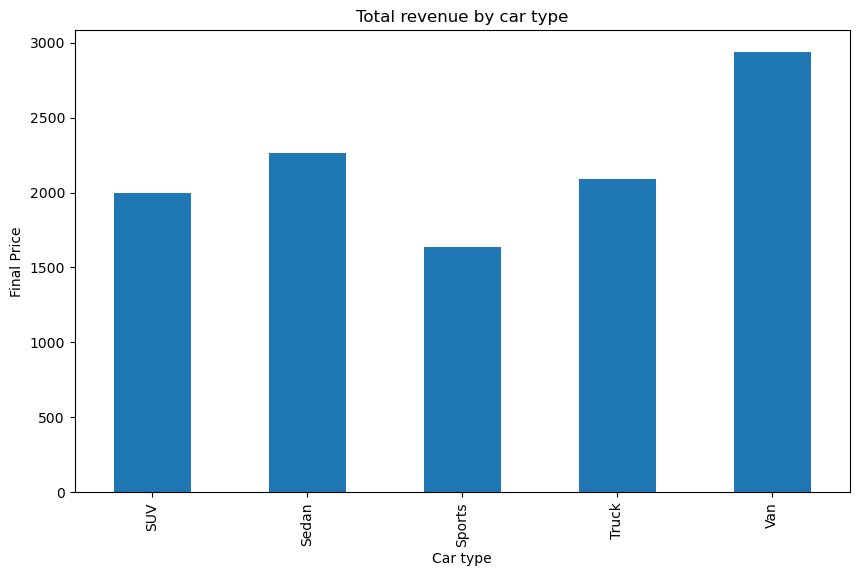

In [56]:
df_bar.plot(x = 'Car Type', y = 'Final Price',kind = 'bar', figsize = (10, 6))
plt.xlabel('Car type')
plt.ylabel('Final Price')
plt.title('Total revenue by car type')
plt.show()

In [63]:
total_rev = df['Final Price'].sum()
print(f'total revenue is {total_rev:.2f}')

total revenue is 10926.06
